In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from tests.test_states_vector import run_clearout_trials

plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

## Plot 1: Discard rate vs initial excited fraction

Sweep $|c_1|^2$ from 0 to 1. For each value, run 2000 MC trials of `make_atom_states -> do_clearout`.
The empirical discard rate should overlap with the analytical line $1 - |c_1|^2$.

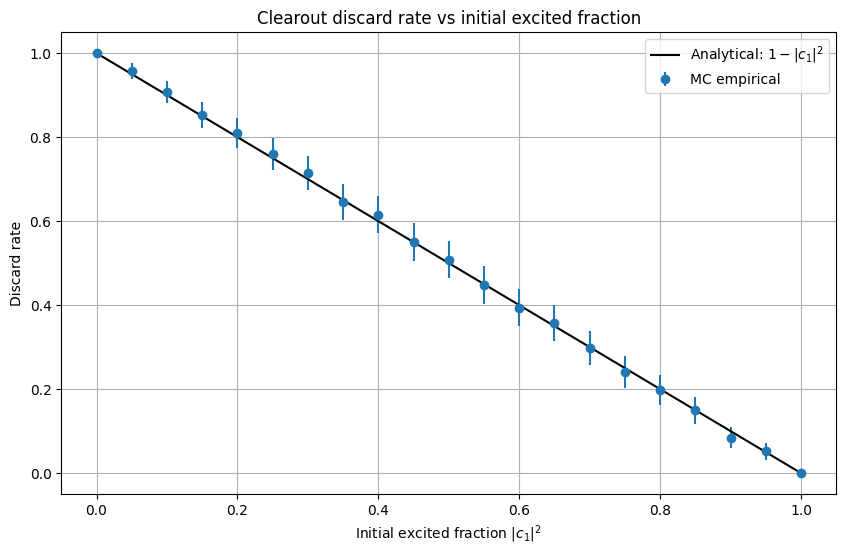

In [2]:
excited_fractions = np.linspace(0, 1, 21)
n_trials = 2000
discard_rates = []
errors = []

for i, ef in enumerate(excited_fractions):
    c1 = np.sqrt(ef)
    c0 = np.sqrt(1 - ef) if ef < 1 else 0.0
    
    n_discards = 0
    for trial in range(n_trials):
        rng = np.random.default_rng(i * n_trials + trial)
        m, pos, vel, amp, isg = sim.make_atom_states(c0=c0, c1=c1)
        omega = 2 * np.pi * sim.TRANSITION_FREQUENCY
        squiggly = sim.transform_state_vector(m, amp, isg, omega_laser=omega, t=0, z=0, vz=0, inverse=False)
        result = sim.do_clearout(m, squiggly, isg, pos, vel, rng=rng)
        if result is None:
            n_discards += 1
    
    rate = n_discards / n_trials
    discard_rates.append(rate)
    errors.append(4.0 * np.sqrt(rate * (1 - rate) / n_trials))

plt.figure()
plt.errorbar(excited_fractions, discard_rates, yerr=errors, fmt='o', label='MC empirical')
plt.plot(excited_fractions, 1 - excited_fractions, 'k-', label='Analytical: $1 - |c_1|^2$')
plt.xlabel('Initial excited fraction $|c_1|^2$')
plt.ylabel('Discard rate')
plt.title('Clearout discard rate vs initial excited fraction')
plt.legend()
plt.grid(True)
plt.show()

## Plot 2: Mach-Zehnder with clearout

Standard pi/2 - pi - pi/2 MZ phase scan with `do_clearout` inserted between the pi and final pi/2 pulses.

Expectations:
- P_discarded ~ 0.5 (atoms in ground after the pi pulse are blown away regardless of phi)
- After clearout only excited-state atoms remain; for a resonant pi pulse these are concentrated in a single momentum branch, so the final pi/2 pulse produces no interference fringe — P_ground and P_excited are flat at ~0.25 each (0.5 of the surviving 0.5 population, split equally by the final pi/2).

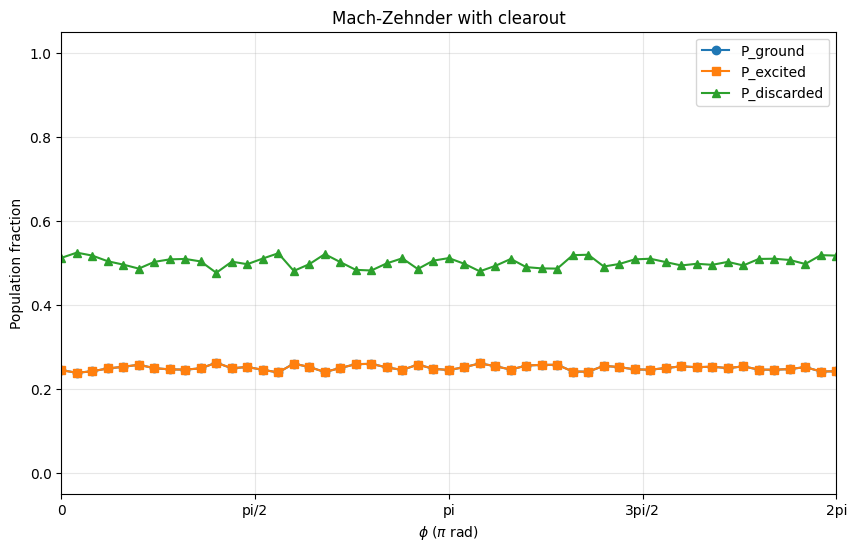

In [3]:
T_FREE = 200e-6
DETUNING_HZ = sim.RECOIL_FREQUENCY_HZ
OMEGA_LASER = 2 * np.pi * (sim.TRANSITION_FREQUENCY + DETUNING_HZ)
CLEAROUT_DURATION = 0.0


def mz_sequence_with_clearout(phi, rng):
    """Run a pi/2 - pi - clearout - pi/2 MZ sequence. Returns state tuple or None."""
    pulse_sequence = [
        seq.Pulse(
            k=+1,
            detuning_hz=DETUNING_HZ,
            phi=0.0,
            label="beam_splitter_1",
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI / 2,
        ),
        seq.Pulse(
            k=+1,
            detuning_hz=DETUNING_HZ,
            phi=phi,
            label="mirror",
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI,
        ),
        seq.Clearout(
            duration=CLEAROUT_DURATION,
            label="mid_sequence_clearout",
        ),
        seq.Pulse(
            k=+1,
            detuning_hz=DETUNING_HZ,
            phi=4 * phi,
            label="beam_splitter_2",
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI / 2,
        ),
    ]

    m, pos, vel, amp, isg = sim.make_atom_states(c0=1, c1=0)
    squiggly = sim.transform_state_vector(
        m, amp, isg, omega_laser=OMEGA_LASER, t=0.0, z=0.0, vz=0.0, inverse=False
    )

    result = seq.run_pulse_sequence_in_borde_representation(
        m,
        pos,
        vel,
        squiggly,
        isg,
        pulse_sequence,
        initial_velocity_z=0.0,
        rng=rng,
    )
    if result is None:
        return None

    m, squiggly, isg, pos, vel, _omega_laser, current_time = result
    amp_final = sim.transform_state_vector(
        m,
        squiggly,
        isg,
        omega_laser=OMEGA_LASER,
        t=current_time,
        z=0.0,
        vz=0.0,
        inverse=True,
    )
    return m, amp_final, isg, pos, vel


phi_values = np.linspace(0, 2 * np.pi, 51)
n_trials = 2000

p_ground = np.empty_like(phi_values)
p_excited = np.empty_like(phi_values)
p_discarded = np.empty_like(phi_values)

for i, phi in enumerate(phi_values):
    rng = np.random.default_rng(1000 + i)
    pg, pe, pd = run_clearout_trials(
        lambda rng: mz_sequence_with_clearout(phi, rng), n_trials=n_trials, rng=rng
    )
    p_ground[i] = pg
    p_excited[i] = pe
    p_discarded[i] = pd

plt.figure()
plt.plot(phi_values / np.pi, p_ground, 'o-', label='P_ground')
plt.plot(phi_values / np.pi, p_excited, 's-', label='P_excited')
plt.plot(phi_values / np.pi, p_discarded, '^-', label='P_discarded')
plt.xlabel(r'$\phi$ ($\pi$ rad)')
plt.ylabel('Population fraction')
plt.title('Mach-Zehnder with clearout')
plt.xticks([0, 0.5, 1, 1.5, 2], ['0', 'pi/2', 'pi', '3pi/2', '2pi'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 2)
plt.ylim(-0.05, 1.05)


## Plot 3: Velocity-selected vs normal Mach-Zehnder

**Velocity selection** narrows the Doppler spread before the MZ sequence:

1. **Selection π-pulse (350 µs)**: Fourier linewidth ≈ 1/(2 × 350 µs) ≈ 1.4 kHz. Only atoms whose Doppler shift falls within this narrow window are transferred to the excited state; off-resonant atoms stay in the ground state.
2. **Clearout**: removes the ground-state (unselected) atoms. The surviving excited-state atoms have a much narrower velocity spread.
3. **MZ sequence (45 µs pulses, 200 µs free evolution)**: runs on the velocity-selected atoms.

At 1 µK, the 1D Maxwell–Boltzmann width is $\sigma_v \approx 9.8$ mm/s, giving a Doppler $\sigma_f \approx 14$ kHz. The 350 µs selection pulse accepts only the slowest ≈ 10 % of atoms but delivers much better fringe contrast because those atoms accumulate nearly identical interferometer phases.

σ_v at 1 µK:        9.78 mm/s
Doppler σ_f:                   14006 Hz
Selection pulse bandwidth:     ≈ 1429 Hz  (10% of Doppler σ)
Normal MZ contrast:            0.543
Velocity-selected MZ contrast: 0.872
Mean discard rate:             0.919


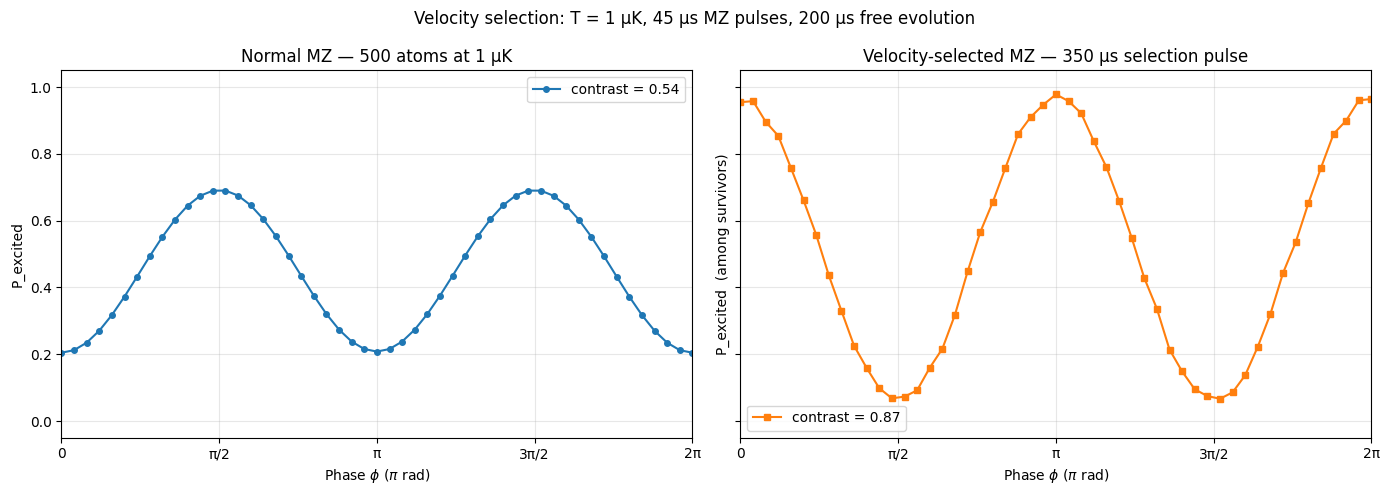

In [4]:
from scipy import constants

# ── Parameters ────────────────────────────────────────────────────────────────
TEMPERATURE_VS = 1e-6                              # 1 µK cloud
sigma_v_vs = np.sqrt(constants.k * TEMPERATURE_VS / sim.MASS_ATOM)

T_PI_SEL = 350e-6                                  # 350 µs selection π-pulse
RABI_FREQ_SEL = 1.0 / (2 * T_PI_SEL)              # Rabi freq for selection pulse

T_FREE_VS = 200e-6                                 # MZ free-evolution interval
MZ_DETUNING_VS = sim.RECOIL_FREQUENCY_HZ
OMEGA_LASER_VS = 2 * np.pi * (sim.TRANSITION_FREQUENCY + MZ_DETUNING_VS)
CLEAROUT_DURATION_VS = 0.0

N_ATOMS_NORMAL = 500                               # ensemble size for normal MZ
N_TRIALS_SEL = 2000                                # MC trials for vel-selected MZ

phi_vs = np.linspace(0, 2 * np.pi, 51)

print(f"σ_v at {TEMPERATURE_VS * 1e6:.0f} µK:        {sigma_v_vs * 1e3:.2f} mm/s")
print(f"Doppler σ_f:                   {sigma_v_vs / sim.TRANSITION_WAVELENGTH:.0f} Hz")
print(f"Selection pulse bandwidth:     ≈ {RABI_FREQ_SEL:.0f} Hz  "
      f"({100 * RABI_FREQ_SEL / (sigma_v_vs / sim.TRANSITION_WAVELENGTH):.0f}% of Doppler σ)")

# ── Helper: single-atom MZ (no velocity selection) ────────────────────────────
def _mz_single(phi, vz):
    """π/2 – T_FREE – π(φ) – T_FREE – π/2 for one atom at velocity vz."""
    m, pos, vel, amp, isg = sim.make_atom_states(c0=1, c1=0, initial_velocity_z=vz)
    t = 0.0
    sq = sim.transform_state_vector(
        m, amp, isg, omega_laser=OMEGA_LASER_VS, t=t, z=0.0, vz=vz, inverse=False
    )

    m, sq, isg, pos, vel = sim.pulse_interaction_in_borde_representation(
        m, sq, isg, pos, vel,
        pulse_detuning=MZ_DETUNING_VS, t_pulse=sim.T_PI / 2,
        pulse_rabi_freq=sim.RABI_FREQ, pulse_phase=0.0,
        k_sign=+1, k_wavevector=sim.K_WAVEVECTOR, vz=vz,
    )
    t += sim.T_PI / 2

    m, sq, isg, pos, vel = sim.propagate_states_in_borde_representation(
        m, sq, isg, pos, vel,
        time_of_propegation=T_FREE_VS, omega_laser=OMEGA_LASER_VS,
        vz=vz, k_sign=+1, k_wavevector=sim.K_WAVEVECTOR,
    )
    t += T_FREE_VS

    m, sq, isg, pos, vel = sim.pulse_interaction_in_borde_representation(
        m, sq, isg, pos, vel,
        pulse_detuning=MZ_DETUNING_VS, t_pulse=sim.T_PI,
        pulse_rabi_freq=sim.RABI_FREQ, pulse_phase=phi,
        k_sign=+1, k_wavevector=sim.K_WAVEVECTOR, vz=vz,
    )
    t += sim.T_PI

    m, sq, isg, pos, vel = sim.propagate_states_in_borde_representation(
        m, sq, isg, pos, vel,
        time_of_propegation=T_FREE_VS, omega_laser=OMEGA_LASER_VS,
        vz=vz, k_sign=+1, k_wavevector=sim.K_WAVEVECTOR,
    )
    t += T_FREE_VS

    m, sq, isg, pos, vel = sim.pulse_interaction_in_borde_representation(
        m, sq, isg, pos, vel,
        pulse_detuning=MZ_DETUNING_VS, t_pulse=sim.T_PI / 2,
        pulse_rabi_freq=sim.RABI_FREQ, pulse_phase=0.0,
        k_sign=+1, k_wavevector=sim.K_WAVEVECTOR, vz=vz,
    )
    t += sim.T_PI / 2

    amp_f = sim.transform_state_vector(
        m, sq, isg, omega_laser=OMEGA_LASER_VS, t=t, z=0.0, vz=vz, inverse=True
    )
    _, p_e = sim.calculate_ground_and_excited_probabilities(m, amp_f, isg)
    return p_e


# ── Helper: velocity-selected MZ trial ────────────────────────────────────────
def _vs_mz_trial(phi, rng):
    """Selection π-pulse + clearout + MZ. Returns state tuple or None."""
    vz = rng.normal(0.0, sigma_v_vs)
    pulse_sequence = [
        seq.Pulse(
            k=+1,
            detuning_hz=MZ_DETUNING_VS,
            phi=0.0,
            label="velocity_selection",
            rabi_frequency=RABI_FREQ_SEL,
            duration=T_PI_SEL,
        ),
        seq.Clearout(
            duration=CLEAROUT_DURATION_VS,
            label="velocity_selection_clearout",
        ),
        seq.Pulse(
            k=+1,
            detuning_hz=MZ_DETUNING_VS,
            phi=0.0,
            label="beam_splitter_1",
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI / 2,
        ),
        seq.Pulse(
            k=+1,
            detuning_hz=MZ_DETUNING_VS,
            phi=phi,
            label="mirror",
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI,
        ),
        seq.Pulse(
            k=+1,
            detuning_hz=MZ_DETUNING_VS,
            phi=0.0,
            label="beam_splitter_2",
            rabi_frequency=sim.RABI_FREQ,
            duration=sim.T_PI / 2,
        ),
    ]

    m, pos, vel, amp, isg = sim.make_atom_states(c0=1, c1=0, initial_velocity_z=vz)
    sq = sim.transform_state_vector(
        m, amp, isg, omega_laser=OMEGA_LASER_VS, t=0.0, z=0.0, vz=vz, inverse=False
    )

    result = seq.run_pulse_sequence_in_borde_representation(
        m,
        pos,
        vel,
        sq,
        isg,
        pulse_sequence,
        initial_velocity_z=vz,
        rng=rng,
    )
    if result is None:
        return None

    m, sq, isg, pos, vel, _omega_laser, t = result
    amp_f = sim.transform_state_vector(
        m, sq, isg, omega_laser=OMEGA_LASER_VS, t=t, z=0.0, vz=vz, inverse=True
    )
    return m, amp_f, isg, pos, vel


# ── Normal MZ fringe (average over thermal ensemble) ─────────────────────────
rng_normal = np.random.default_rng(42)
v_ensemble = rng_normal.normal(0.0, sigma_v_vs, size=N_ATOMS_NORMAL)

pe_normal = np.empty_like(phi_vs)
for i, phi in enumerate(phi_vs):
    pe_normal[i] = np.mean([_mz_single(phi, vz) for vz in v_ensemble])

# ── Velocity-selected MZ fringe ───────────────────────────────────────────────
pe_sel = np.empty_like(phi_vs)
pd_sel = np.empty_like(phi_vs)

for i, phi in enumerate(phi_vs):
    rng_i = np.random.default_rng(300 + i)
    pg, pe, pd = run_clearout_trials(
        lambda rng, _phi=phi: _vs_mz_trial(_phi, rng),
        n_trials=N_TRIALS_SEL,
        rng=rng_i,
    )
    # Normalise to the surviving-atom population
    pe_sel[i] = pe / (1.0 - pd) if pd < 1.0 else 0.0
    pd_sel[i] = pd

# ── Plot ──────────────────────────────────────────────────────────────────────
def _contrast(p):
    lo, hi = p.min(), p.max()
    return (hi - lo) / (hi + lo) if hi + lo > 0 else 0.0

c_normal = _contrast(pe_normal)
c_sel = _contrast(pe_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(phi_vs / np.pi, pe_normal, 'o-', color='tab:blue', ms=4,
             label=f'contrast = {c_normal:.2f}')
axes[0].set_title(f'Normal MZ — {N_ATOMS_NORMAL} atoms at {TEMPERATURE_VS * 1e6:.0f} µK')
axes[0].set_ylabel('P_excited')

axes[1].plot(phi_vs / np.pi, pe_sel, 's-', color='tab:orange', ms=4,
             label=f'contrast = {c_sel:.2f}')
axes[1].set_title('Velocity-selected MZ — 350 µs selection pulse')
axes[1].set_ylabel('P_excited  (among survivors)')

for ax in axes:
    ax.set_xlabel(r'Phase $\phi$ ($\pi$ rad)')
    ax.set_xticks([0, 0.5, 1, 1.5, 2])
    ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
    ax.set_xlim(0, 2)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Velocity selection: T = {TEMPERATURE_VS * 1e6:.0f} µK, '
    f'45 µs MZ pulses, {T_FREE_VS * 1e6:.0f} µs free evolution',
    fontsize=12,
)


print(f"Normal MZ contrast:            {c_normal:.3f}")
print(f"Velocity-selected MZ contrast: {c_sel:.3f}")
print(f"Mean discard rate:             {pd_sel.mean():.3f}")
